# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
path = "../data/raw/PS_20174392719_1491204439457_log.csv"

In [3]:
df = pd.read_csv(path)

## Exploratory Data Analysis

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [6]:
downcasting = {
    'step': 'int32',
    'type': 'category',
    'amount': 'float32',
    'nameOrig': 'string',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'string',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8'
}

df = df.astype(downcasting)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        string  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        string  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int32(1), int8(2), string(2)
memory usage: 388.1 MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551136e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924048e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
# Check for missing values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [9]:
# check duplicates value
print(df.duplicated().sum())

0


In [10]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

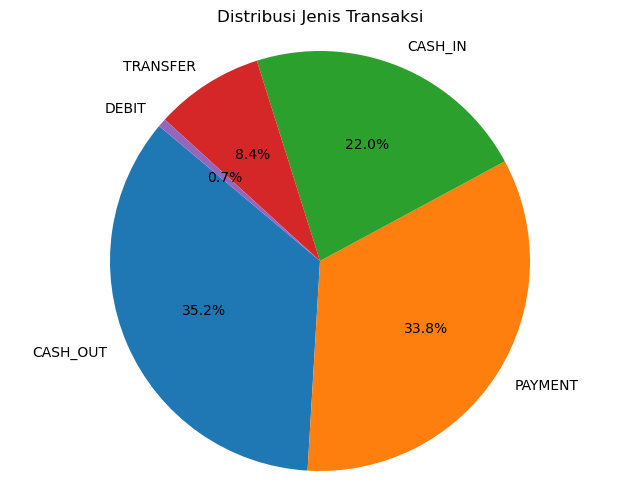

In [11]:
# Distribusi Transaksi
plt.figure(figsize=(8, 6))
plt.pie(df['type'].value_counts().values, labels=df['type'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Distribusi Jenis Transaksi')
plt.axis('equal')
plt.show()

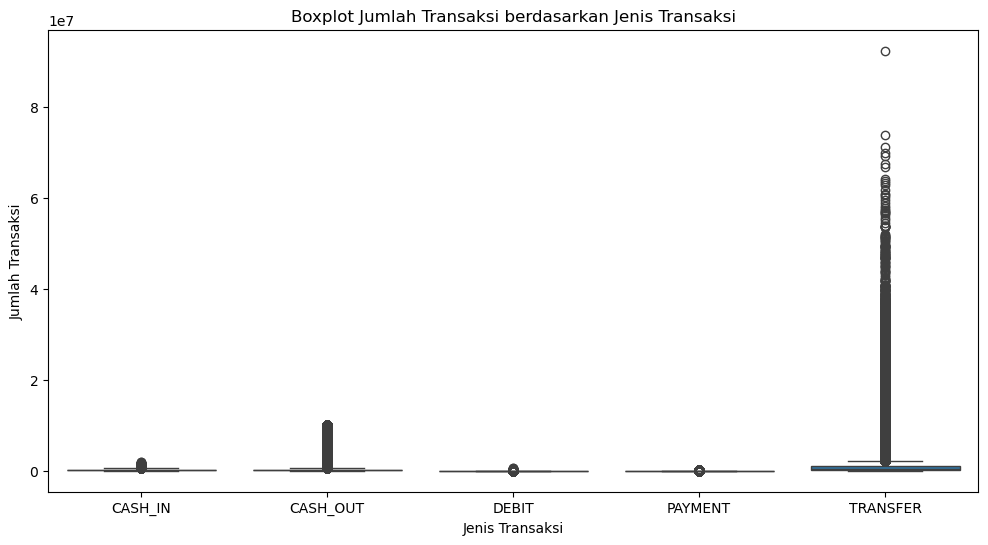

In [12]:
# Visualisasi Outlier Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='amount', data=df)
plt.title('Boxplot Jumlah Transaksi berdasarkan Jenis Transaksi')
plt.xlabel('Jenis Transaksi')
plt.ylabel('Jumlah Transaksi')
plt.show()


In [13]:
# check transaksi merchant apakah benar-benar semuanya memiliki saldo 0
merchant_data = df[df['nameDest'].str.startswith('M')]
print(f"Jumlah transaksi ke Merchant: {len(merchant_data)}")
print("\nStatistik Saldo Merchant (Harusnya semua 0):")
print("Max Old Balance Dest:", merchant_data['oldbalanceDest'].max())
print("Max New Balance Dest:", merchant_data['newbalanceDest'].max())

Jumlah transaksi ke Merchant: 2151495

Statistik Saldo Merchant (Harusnya semua 0):
Max Old Balance Dest: 0.0
Max New Balance Dest: 0.0


In [14]:
fraud_counts = df['isFraud'].value_counts()
print("DISTRIBUSI FRAUD LABEL:")
print(fraud_counts)
print(f"Persentase Fraud: {(fraud_counts[1] / len(df)) * 100:.4f}%")

DISTRIBUSI FRAUD LABEL:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Persentase Fraud: 0.1291%


Kesimpulan hasil EDA :

- Dataset Raw data memiliki ukuran yang sangat besar yaitu 6.362.620 baris
- Untuk efisiensi dalam EDA dan selanjutnya saya melakukan downcasting dengan tetap memperhatikan basis data dalam dataset
- Disini data transaksi didominasi oleh CASH OUT dengan dominasi 35,2%
- Terdapat nilai outlier yang ekstrim pada column amount terutama pada jenis TRANSFER dan CASH OUT
- Tervalidasi bahwa memanhg benar pada penerimaan berawal M 'Merchant' saldo awal dan akhir bernilai 0
- Dari semua transaksi yang bernilai fraud asli yaitu 8.213 kasus